# 🐼 Jour 1 (suite) — Les `Series` pandas

**Objectif :** comprendre la brique de base de pandas : la **Series** (tableau à 1 dimension), avant de passer aux DataFrames (2 dimensions).

In [1]:
import pandas as pd
import numpy as np


Type:        module
String form: <module 'pandas' from 'c:\\Users\\kirit\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\pandas\\__init__.py'>
File:        c:\users\kirit\appdata\local\programs\python\python312\lib\site-packages\pandas\__init__.py
Docstring:  
pandas - a powerful data analysis and manipulation library for Python

**pandas** is a Python package providing fast, flexible, and expressive data
structures designed to make working with "relational" or "labeled" data both
easy and intuitive. It aims to be the fundamental high-level building block for
doing practical, **real world** data analysis in Python. Additionally, it has
the broader goal of becoming **the most powerful and flexible open source data
analysis / manipulation tool available in any language**. It is already well on
its way toward this goal.

Main Features
-------------
Here are just a few of the things that pandas does well:

  - Easy handling of missing data in floating point as well as non

### Qu'est-ce qu'une Series ?
`pd.Series([1,2,3])` crée un tableau **1D** composé de deux parties :
- les **valeurs** (1, 2, 3)
- un **index** (0, 1, 2 par défaut) — l'étiquette de chaque valeur

C'est ce qui distingue une Series d'une simple liste Python : chaque valeur a une étiquette, et les opérations s'alignent sur cet index.

In [3]:
pd.Series([1,2,3])

0    1
1    2
2    3
dtype: int64

Création d'une Series de 9 valeurs, stockée dans une variable pour la réutiliser.

In [5]:
my_series = pd.Series([1,2,3,10,10,20,30,50,100])

In [6]:
my_series

0      1
1      2
2      3
3     10
4     10
5     20
6     30
7     50
8    100
dtype: int64

`.head(2)` : les 2 premières valeurs — fonctionne comme sur un DataFrame.

In [7]:
my_series.head(2)

0    1
1    2
dtype: int64

`.plot()` : trace les **valeurs** (axe y) en fonction de l'**index** (axe x) sous forme de courbe.

**🔍 Comment interpréter ce graphique :** la série vaut `[1,2,3,10,10,20,30,50,100]` — tu devrais voir une courbe globalement **croissante**, avec une pente qui s'accentue vers la fin (les derniers points montent plus vite que les premiers). ⚠️ Ici l'axe X (l'index 0 à 8) n'a pas de signification particulière (ce n'est ni une date, ni une mesure) — un graphique en courbe n'est vraiment utile que si l'ordre des points a un sens (le temps, par exemple). Pour une série sans ordre naturel, un histogramme ou un simple tableau de valeurs serait souvent plus parlant.

<Axes: >

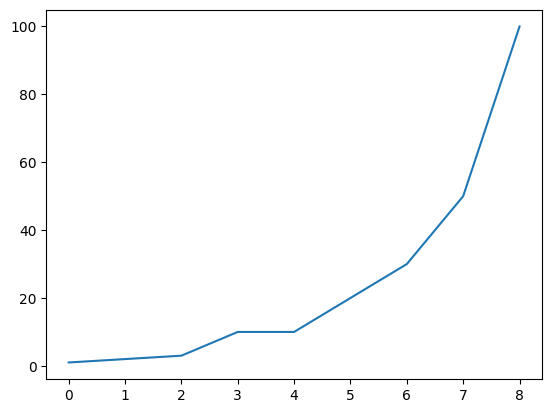

In [8]:
my_series.plot()

### Concaténer des Series
`pd.concat([s1, s2])` **colle** les Series bout à bout → une Series de 18 valeurs.

⚠️ Regarde bien l'affichage suivant : l'**index est dupliqué** (0…8 puis à nouveau 0…8), car `concat` conserve les index d'origine. C'est une source classique de bugs (deux lignes avec la même étiquette).

In [9]:
superseries = pd.concat([my_series,my_series])

On voit le problème : chaque numéro d'index apparaît **deux fois**.

In [11]:
superseries

0      1
1      2
2      3
3     10
4     10
5     20
6     30
7     50
8    100
0      1
1      2
2      3
3     10
4     10
5     20
6     30
7     50
8    100
dtype: int64

### `reset_index()` : réparer l'index
`reset_index()` recrée un index propre 0…n−1. Mais **sans** `drop=True`, l'ancien index est conservé comme **nouvelle colonne** → le résultat devient un **DataFrame** à 2 colonnes (l'ancien index + les valeurs). C'est ce que confirme `type(...)`.

In [12]:
type(superseries.reset_index())

pandas.DataFrame

Avec `drop=True`, l'ancien index est **jeté** : on garde une **Series** avec un index tout neuf 0…17. 👉 C'est généralement ce qu'on veut après un `concat`.

In [13]:
superseries.reset_index(drop = True)

0       1
1       2
2       3
3      10
4      10
5      20
6      30
7      50
8     100
9       1
10      2
11      3
12     10
13     10
14     20
15     30
16     50
17    100
dtype: int64

Comparaison : la version **sans** `drop=True` — on voit la colonne `index` (l'ancien index) apparaître à côté des valeurs, et l'objet est devenu un DataFrame.

In [10]:
superseries.reset_index()

,index,0
0,0,1
1,1,2
2,2,3
3,3,10
4,4,10
5,5,20
6,6,30
7,7,50
8,8,100
9,0,1
